In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub 

/kaggle/input/datasets/mansiaggarwal88/diabetes-risk-prediction/generate_dataset.py
/kaggle/input/datasets/mansiaggarwal88/diabetes-risk-prediction/diabetes_risk.csv


In [34]:
df = pd.read_csv("/kaggle/input/datasets/mansiaggarwal88/diabetes-risk-prediction/diabetes_risk.csv")

In [35]:
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

In [37]:
df.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000


In [38]:
df.describe(include = object)

,gender,city,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,income_bracket,diabetes_risk
count,15000,15000,15000,15000,15000,14528,11212,14537,15000
unique,3,18,2,3,4,3,3,3,3
top,Male,Mumbai,No,Active,Non-Vegetarian,Never,Never,Middle,Low
freq,7664,2243,9756,5100,8195,10119,5616,7305,9000


In [39]:
df.isnull().sum()

patient_id                     0
age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type                      0
smoking_status               472
alcohol_consumption         3788
hours_sleep_per_night          0
stress_level                   0
fasting_blood_sugar            0
hba1c_level                    0
blood_pressure_systolic        0
blood_pressure_diastolic       0
waist_circumference_cm         0
income_bracket               463
diabetes_risk                  0
dtype: int64

In [40]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [41]:
df['smoking_status'] = df['smoking_status'].fillna('unknown')
df['alcohol_consumption'] = df['alcohol_consumption'].fillna('unknown')
df['income_bracket'] = df['income_bracket'].fillna('unknown')

In [42]:
df.drop('patient_id',axis=1,inplace=True)

EDA

In [43]:
df['diabetes_risk'].value_counts()

diabetes_risk
Low         9000
Moderate    3750
High        2250
Name: count, dtype: int64

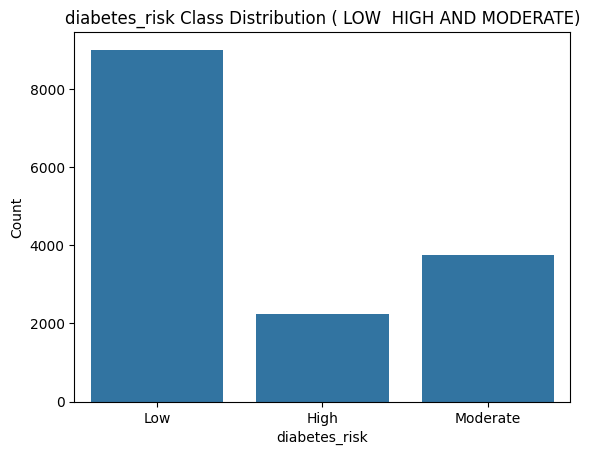

In [44]:
plt.figure()
sns.countplot(x='diabetes_risk', data=df)
plt.title('diabetes_risk Class Distribution ( LOW  HIGH AND MODERATE)')
plt.xlabel('diabetes_risk')
plt.ylabel('Count')
plt.show()

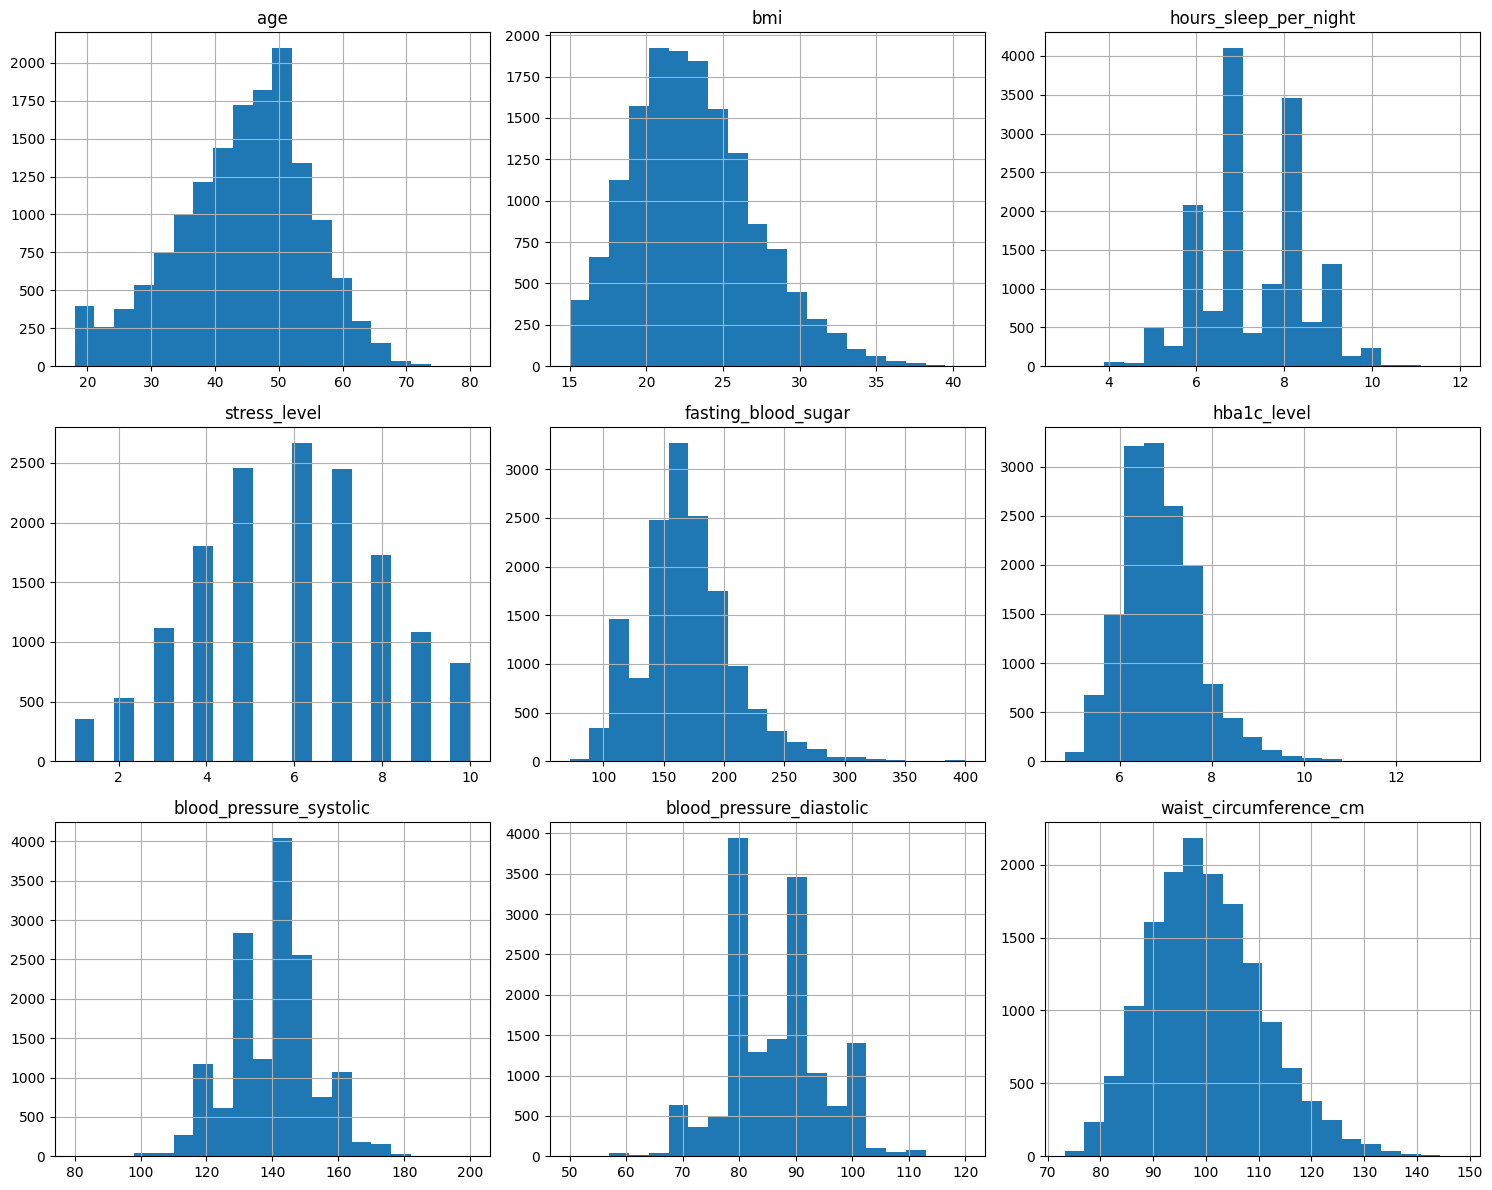

In [45]:
numeric_columns = df.select_dtypes(include='number').columns
df[numeric_columns].hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

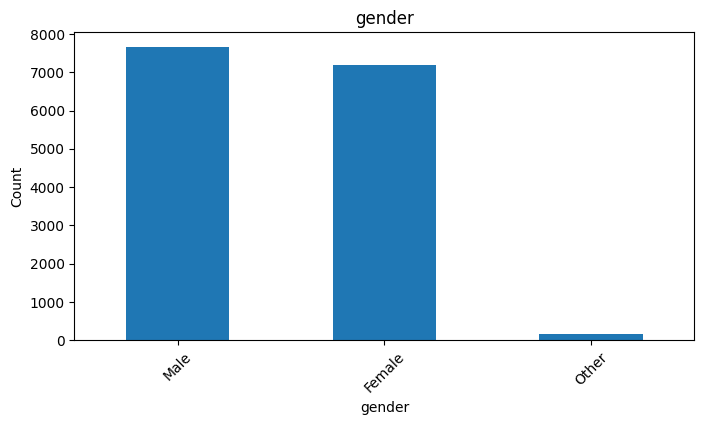

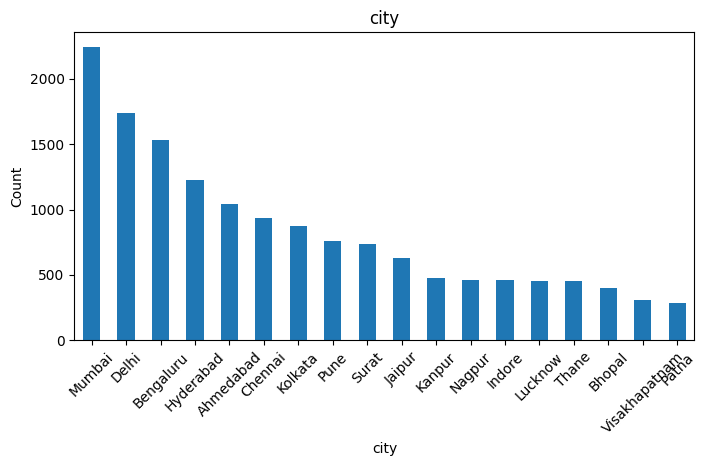

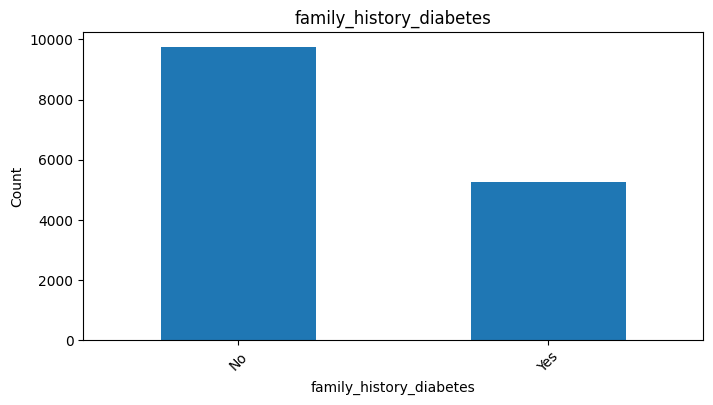

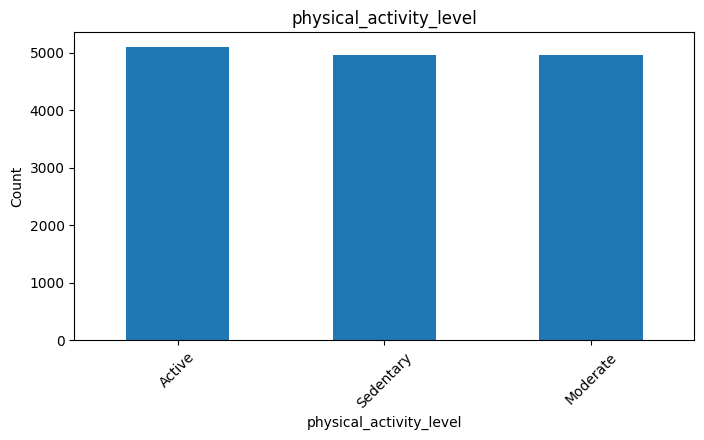

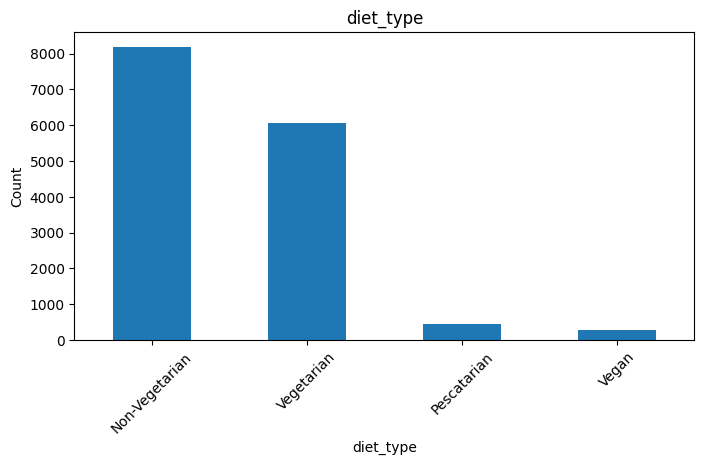

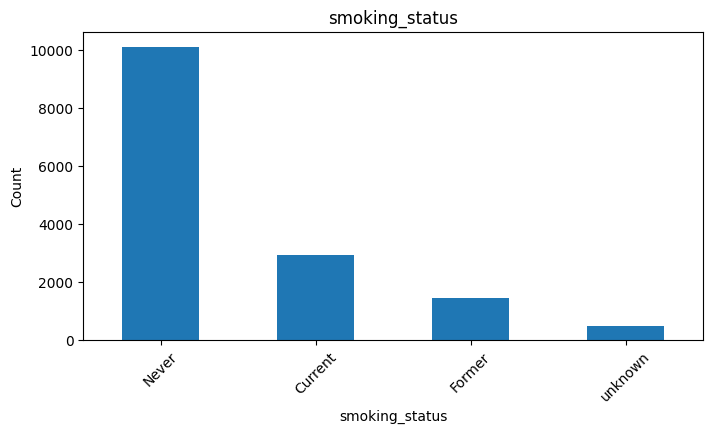

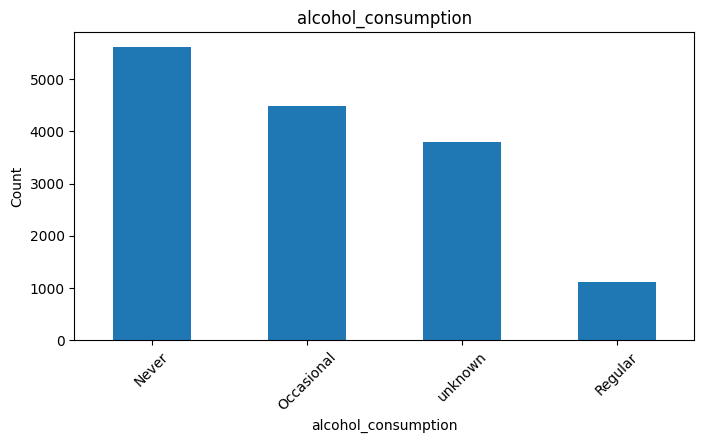

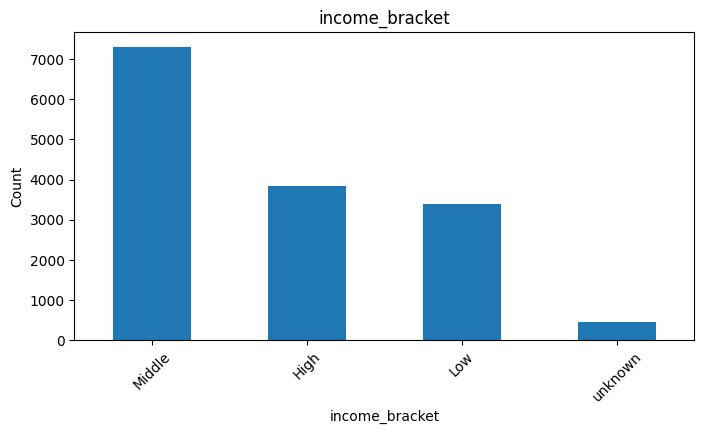

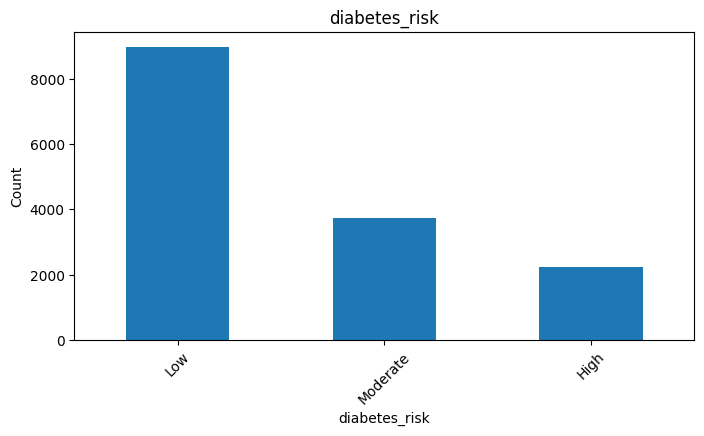

In [46]:
import matplotlib.pyplot as plt

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    df[column].value_counts().plot(kind='bar', figsize=(8, 4))
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

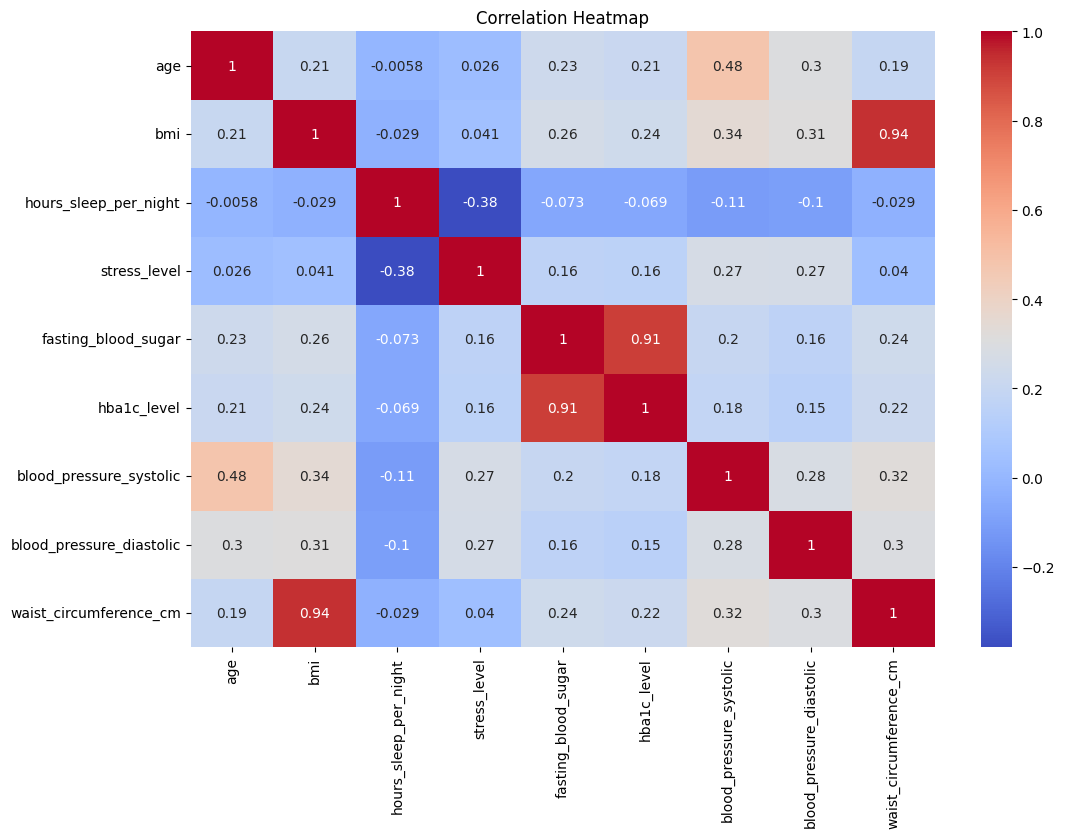

In [47]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [48]:
df

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,47,Male,Mumbai,37.7,No,Sedentary,Non-Vegetarian,Never,Never,6.8,7,213,8.1,150,100,141.7,High,High
14996,48,Female,Mumbai,20.6,No,Moderate,Non-Vegetarian,Never,unknown,6.0,8,162,6.5,132,80,91.0,unknown,Low
14997,34,Female,Nagpur,17.9,No,Active,Vegetarian,Never,Never,7.0,6,137,6.5,136,90,88.8,Low,Low
14998,56,Male,Ahmedabad,20.7,Yes,Active,Vegetarian,Never,Never,6.0,5,163,6.9,140,87,94.8,Low,Low


In [49]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
le = LabelEncoder()

In [50]:
for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

In [51]:
df

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,47,0,11,26.5,1,2,3,2,0,9.0,8,178,7.3,146,90,107.1,0,1
1,53,0,11,20.5,1,1,3,2,0,7.0,6,152,6.9,156,100,93.8,1,1
2,47,1,16,31.3,0,1,0,0,2,7.0,7,168,6.6,150,102,113.5,1,0
3,41,1,1,22.8,0,2,0,2,0,9.0,5,155,6.7,126,92,109.6,2,1
4,57,0,1,16.7,0,2,0,0,1,6.5,10,188,6.7,130,90,80.8,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,47,1,11,37.7,0,2,0,2,0,6.8,7,213,8.1,150,100,141.7,0,0
14996,48,0,11,20.6,0,1,0,2,3,6.0,8,162,6.5,132,80,91.0,3,1
14997,34,0,12,17.9,0,0,3,2,0,7.0,6,137,6.5,136,90,88.8,1,1
14998,56,1,0,20.7,1,0,3,2,0,6.0,5,163,6.9,140,87,94.8,1,1


In [52]:
# bmi chages to numeric encoding 
# • Underweight: BMI less than 18.5
"""• Healthy Weight: BMI of 18.5 to 24.9
• Overweight: BMI of 25.0 to 29.9
• Class 1 Obesity: BMI of 30.0 to 34.9
• Class 2 Obesity: BMI of 35.0 to 39.9
• Class 3 Obesity (Severe): BMI of 40.0 or higher"""

"""hba1c_level	

| HbA1c level       | Meaning        |
| ----------------- | -------------- |
| **Below 5.7%**    | Normal         |
| **5.7% – 6.4%**   | Prediabetes    |
| **6.5% or above** | Diabetes range |
"""


# blood_pressure_systolic    <120 
# blood_pressure_diastolic    < 80
""" • Low (Hypotension): Less than 90 mm Hg systolic and less than 60 mm Hg diastolic.
• Normal: Less than 120 mm Hg systolic and less than 80 mm Hg diastolic.
• Elevated: 120–129 mm Hg systolic and less than 80 mm Hg diastolic.
• Stage 1 Hypertension: 130–139 mm Hg systolic or 80–89 mm Hg diastolic.
• Stage 2 Hypertension: 140 mm Hg or higher systolic, or 90 mm Hg or higher diastolic.
• Hypertensive Crisis: Higher than 180 mm Hg systolic and/or higher than 120 mm Hg diastolic (seek emergency care immediately). """# bmi chages to numeric encoding 
# • Underweight: BMI less than 18.5
"""• Healthy Weight: BMI of 18.5 to 24.9
• Overweight: BMI of 25.0 to 29.9
• Class 1 Obesity: BMI of 30.0 to 34.9
• Class 2 Obesity: BMI of 35.0 to 39.9
• Class 3 Obesity (Severe): BMI of 40.0 or higher"""

"""hba1c_level	

| HbA1c level       | Meaning        |
| ----------------- | -------------- |
| **Below 5.7%**    | Normal         |
| **5.7% – 6.4%**   | Prediabetes    |
| **6.5% or above** | Diabetes range |
"""


# blood_pressure_systolic    <120 
# blood_pressure_diastolic    < 80
""" • Low (Hypotension): Less than 90 mm Hg systolic and less than 60 mm Hg diastolic.
• Normal: Less than 120 mm Hg systolic and less than 80 mm Hg diastolic.
• Elevated: 120–129 mm Hg systolic and less than 80 mm Hg diastolic.
• Stage 1 Hypertension: 130–139 mm Hg systolic or 80–89 mm Hg diastolic.
• Stage 2 Hypertension: 140 mm Hg or higher systolic, or 90 mm Hg or higher diastolic.
• Hypertensive Crisis: Higher than 180 mm Hg systolic and/or higher than 120 mm Hg diastolic (seek emergency care immediately). """


df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[-np.inf, 18.5, 24.9, 29.9, 34.9, 39.9, np.inf],
    labels=[
        'Underweight',
        'Healthy',
        'Overweight',
        'Obesity_Class_1',
        'Obesity_Class_2',
        'Obesity_Class_3'
    ]
)

# Numeric encoding
bmi_map = {
    'Underweight': 0,
    'Healthy': 1,
    'Overweight': 2,
    'Obesity_Class_1': 3,
    'Obesity_Class_2': 4,
    'Obesity_Class_3': 5
}

df['bmi_category'] = df['bmi_category'].map(bmi_map)


# 2. HbA1c CATEGORY

df['hba1c_category'] = pd.cut(
    df['hba1c_level'],
    bins=[-np.inf, 5.7, 6.5, np.inf],
    labels=['Normal', 'Prediabetes', 'Diabetes']
)

hba1c_map = {
    'Normal': 0,
    'Prediabetes': 1,
    'Diabetes': 2
}

df['hba1c_category'] = df['hba1c_category'].map(hba1c_map)


# 3. BLOOD PRESSURE CATEGORY

def bp_category(row):
    systolic = row['blood_pressure_systolic']
    diastolic = row['blood_pressure_diastolic']

    if systolic > 180 or diastolic > 120:
        return 5                         # Crisis

    elif systolic >= 140 or diastolic >= 90:
        return 4                         # Stage 2

    elif systolic >= 130 or diastolic >= 80:
        return 3                         # Stage 1

    elif systolic >= 120 and diastolic < 80:
        return 2                         # Elevated

    elif systolic < 90 and diastolic < 60:
        return 0                         # Low

    else:
        return 1                         # Normal


df['bp_category'] = df.apply(bp_category, axis=1)

In [53]:
df

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,...,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk,bmi_category,hba1c_category,bp_category
0,47,0,11,26.5,1,2,3,2,0,9.0,...,178,7.3,146,90,107.1,0,1,2,2,4
1,53,0,11,20.5,1,1,3,2,0,7.0,...,152,6.9,156,100,93.8,1,1,1,2,4
2,47,1,16,31.3,0,1,0,0,2,7.0,...,168,6.6,150,102,113.5,1,0,3,2,4
3,41,1,1,22.8,0,2,0,2,0,9.0,...,155,6.7,126,92,109.6,2,1,1,2,4
4,57,0,1,16.7,0,2,0,0,1,6.5,...,188,6.7,130,90,80.8,0,1,0,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,47,1,11,37.7,0,2,0,2,0,6.8,...,213,8.1,150,100,141.7,0,0,4,2,4
14996,48,0,11,20.6,0,1,0,2,3,6.0,...,162,6.5,132,80,91.0,3,1,1,1,3
14997,34,0,12,17.9,0,0,3,2,0,7.0,...,137,6.5,136,90,88.8,1,1,0,1,4
14998,56,1,0,20.7,1,0,3,2,0,6.0,...,163,6.9,140,87,94.8,1,1,1,2,4


In [54]:
df[['bmi', 'bmi_category',
    'hba1c_level', 'hba1c_category',
    'blood_pressure_systolic',
    'blood_pressure_diastolic',
    'bp_category']].head(10)

,bmi,bmi_category,hba1c_level,hba1c_category,blood_pressure_systolic,blood_pressure_diastolic,bp_category
0,26.5,2,7.3,2,146,90,4
1,20.5,1,6.9,2,156,100,4
2,31.3,3,6.6,2,150,102,4
3,22.8,1,6.7,2,126,92,4
4,16.7,0,6.7,2,130,90,4
5,22.0,1,6.3,1,148,100,4
6,22.5,1,7.5,2,140,81,4
7,19.5,1,8.9,2,136,80,3
8,20.3,1,7.4,2,170,91,4
9,24.1,1,7.6,2,150,90,4


In [55]:
sc = StandardScaler()

In [56]:
x = df.drop('diabetes_risk' , axis = 1)
y = df['diabetes_risk']

In [57]:
from sklearn.model_selection import train_test_split,cross_val_score
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2 , random_state = 42)

In [58]:
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.fit_transform(x_test)

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (RandomForestClassifier,BaggingClassifier,ExtraTreesClassifier)
from sklearn.ensemble import (AdaBoostClassifier,GradientBoostingClassifier,HistGradientBoostingClassifier)
from xgboost import XGBClassifier

In [60]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    
    "Naive Bayes": GaussianNB(),
    
    "Decision Tree": DecisionTreeClassifier(max_depth=10,min_samples_split=5,min_samples_leaf=2,random_state=42),

    "SVM": SVC(kernel='rbf',C=1.0,gamma='scale',probability=True,random_state=42),
    
    "KNN": KNeighborsClassifier(n_neighbors=5,weights='distance',metric='minkowski'),

    "Random Forest": RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_split=5,min_samples_leaf=2,max_features='sqrt',random_state=42,n_jobs=-1),

    "Extra Trees": ExtraTreesClassifier(n_estimators=200,max_depth=10,min_samples_split=5,min_samples_leaf=2,max_features='sqrt',random_state=42,n_jobs=-1),

    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=10,
            random_state=42
        ),
        n_estimators=100,
        max_samples=0.8,
        max_features=0.8,
        random_state=42,
        n_jobs=-1
    ),


    # =========================
    # BOOSTING ALGORITHMS
    # =========================

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=5,
        min_samples_leaf=2,
        subsample=0.8,
        random_state=42
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )
}

In [61]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        x_train_scaled,
        y_train,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    results.append({
        'Model': name,
        'CV Mean F1': scores.mean(),
        'CV Std': scores.std()
    })

    print(f"{name}")
    print(f"CV Scores : {scores}")
    print(f"Mean F1   : {scores.mean():.4f}")
    print(f"Std F1    : {scores.std():.4f}")

Logistic Regression
CV Scores : [0.74612595 0.73908026 0.74623018 0.72600645 0.73941047]
Mean F1   : 0.7394
Std F1    : 0.0074
Naive Bayes
CV Scores : [0.70304921 0.69336249 0.67553007 0.67850803 0.67302876]
Mean F1   : 0.6847
Std F1    : 0.0116
Decision Tree
CV Scores : [0.67776635 0.70348182 0.68293963 0.66783946 0.6808977 ]
Mean F1   : 0.6826
Std F1    : 0.0117
SVM
CV Scores : [0.7316122  0.72968233 0.72620005 0.7264609  0.73793994]
Mean F1   : 0.7304
Std F1    : 0.0043
KNN
CV Scores : [0.64513217 0.63173159 0.64204506 0.62047949 0.63370101]
Mean F1   : 0.6346
Std F1    : 0.0087
Random Forest
CV Scores : [0.73460719 0.72861292 0.73797647 0.73214472 0.74364388]
Mean F1   : 0.7354
Std F1    : 0.0051
Extra Trees
CV Scores : [0.69034592 0.68529809 0.70982582 0.71350559 0.71279253]
Mean F1   : 0.7024
Std F1    : 0.0120
Bagging
CV Scores : [0.73117628 0.71624172 0.73300539 0.72962733 0.74167291]
Mean F1   : 0.7303
Std F1    : 0.0082
AdaBoost
CV Scores : [0.72121846 0.70919941 0.73594057 0

In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

top_models = {
    "Logistic Regression": models["Logistic Regression"],
    "Gradient Boosting": models["Gradient Boosting"],
    "Random Forest": models["Random Forest"]
}

test_results = []

for name, model in top_models.items():

    if name == "Logistic Regression":
        x_train_model = x_train_scaled
        x_test_model = x_test_scaled
    else:
        x_train_model = x_train
        x_test_model = x_test

    model.fit(x_train_model, y_train)

    y_pred = model.predict(x_test_model)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    test_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })


    print(name)


    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=['Low', 'Moderate', 'High']
    ))

Logistic Regression
Accuracy  : 0.8023
Precision : 0.7666
Recall    : 0.7466
F1 Score  : 0.7559

Classification Report:
              precision    recall  f1-score   support

         Low       0.81      0.75      0.78       432
    Moderate       0.87      0.90      0.89      1819
        High       0.62      0.59      0.60       749

    accuracy                           0.80      3000
   macro avg       0.77      0.75      0.76      3000
weighted avg       0.80      0.80      0.80      3000

Gradient Boosting
Accuracy  : 0.8017
Precision : 0.7678
Recall    : 0.7419
F1 Score  : 0.7538

Classification Report:
              precision    recall  f1-score   support

         Low       0.82      0.73      0.77       432
    Moderate       0.87      0.91      0.89      1819
        High       0.62      0.58      0.60       749

    accuracy                           0.80      3000
   macro avg       0.77      0.74      0.75      3000
weighted avg       0.80      0.80      0.80      3000



In [63]:
test_results_df = pd.DataFrame(test_results)

test_results_df = test_results_df.sort_values(
    by='F1 Score',
    ascending=False
)

test_results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.803667,0.775340,0.745739,0.759102
0,Logistic Regression,0.802333,0.766574,0.746636,0.755940
1,Gradient Boosting,0.801667,0.767840,0.741889,0.753772


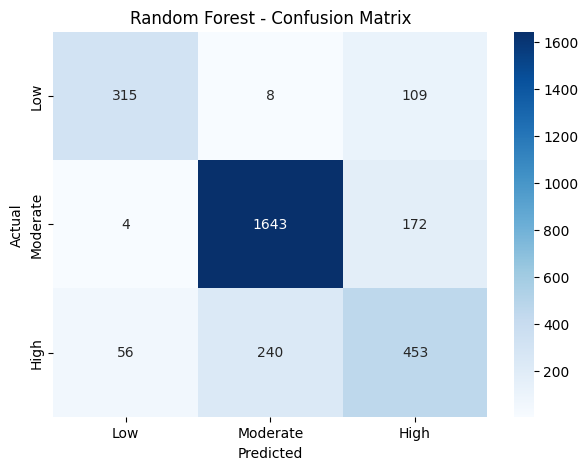

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train final Random Forest
best_model = models["Random Forest"]

best_model.fit(x_train, y_train)

# Prediction
y_pred = best_model.predict(x_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Moderate', 'High'],
    yticklabels=['Low', 'Moderate', 'High']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')

plt.show()

In [66]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced_subsample']
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Macro F1:")
print(random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'class_weight': 'balanced_subsample'}

Best CV Macro F1:
0.7402403028418779


In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

best_rf = random_search.best_estimator_

# Test prediction
y_pred_tuned = best_rf.predict(x_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred_tuned)
precision = precision_score(y_test, y_pred_tuned, average='macro')
recall = recall_score(y_test, y_pred_tuned, average='macro')
f1 = f1_score(y_test, y_pred_tuned, average='macro')

print("=" * 50)
print("TUNED RANDOM FOREST")
print("=" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=['Low', 'Moderate', 'High']
))

TUNED RANDOM FOREST
Accuracy  : 0.7993
Precision : 0.7649
Recall    : 0.7621
F1 Score  : 0.7627

Classification Report:
              precision    recall  f1-score   support

         Low       0.81      0.76      0.78       432
    Moderate       0.89      0.87      0.88      1819
        High       0.59      0.66      0.62       749

    accuracy                           0.80      3000
   macro avg       0.76      0.76      0.76      3000
weighted avg       0.81      0.80      0.80      3000



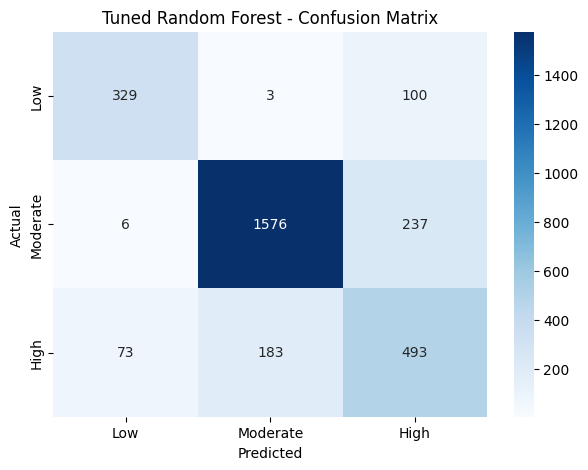

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Moderate', 'High'],
    yticklabels=['Low', 'Moderate', 'High']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned Random Forest - Confusion Matrix')

plt.show()

In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned, average='macro'))
print("Recall   :", recall_score(y_test, y_pred_tuned, average='macro'))
print("F1 Score :", f1_score(y_test, y_pred_tuned, average='macro'))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=['Low', 'Moderate', 'High']
))

Accuracy : 0.7993333333333333
Precision: 0.7649288637043555
Recall   : 0.7620650458175655
F1 Score : 0.762660082098125

Classification Report:
              precision    recall  f1-score   support

         Low       0.81      0.76      0.78       432
    Moderate       0.89      0.87      0.88      1819
        High       0.59      0.66      0.62       749

    accuracy                           0.80      3000
   macro avg       0.76      0.76      0.76      3000
weighted avg       0.81      0.80      0.80      3000



In [70]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Base models
base_models = [
    (
        'lr',
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                max_iter=2000,
                random_state=42
            ))
        ])
    ),

    (
        'rf',
        RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_split=10,
            min_samples_leaf=1,
            max_features='log2',
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1
        )
    ),

    (
        'gb',
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            min_samples_split=5,
            min_samples_leaf=2,
            subsample=0.8,
            random_state=42
        )
    ),

    (
        'xgb',
        XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            min_child_weight=2,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective='multi:softprob',
            eval_metric='mlogloss',
            random_state=42,
            n_jobs=-1
        )
    )
]

# Meta model
meta_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Stacking model
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

In [72]:
stacking_model.fit(x_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('lr',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model',
                                                 LogisticRegression(max_iter=2000,
                                                                    random_state=42))])),
                               ('rf',
                                RandomForestClassifier(class_weight='balanced_subsample',
                                                       max_depth=15,
                                                       max_features='log2',
                                                       min_samples_split=10,
                                                       n_estimators=200,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(learni...
                                              learning_rate=0.05, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=6,
                                              max_leaves=None,
                                              min_child_weight=2, missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=200, n_jobs=-1,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(max_iter=2000,
                                                      random_state=42),
                   n_jobs=-1, stack_method='predict_proba')

In [74]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred_stack = stacking_model.predict(x_test)

print("=" * 50)
print("STACKING CLASSIFIER")
print("=" * 50)

print(f"Accuracy  : {accuracy_score(y_test, y_pred_stack):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_stack, average='macro'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_stack, average='macro'):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_stack, average='macro'):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_stack,
    target_names=['Low', 'Moderate', 'High']
))

STACKING CLASSIFIER
Accuracy  : 0.8060
Precision : 0.7674
Recall    : 0.7523
F1 Score  : 0.7593

Classification Report:
              precision    recall  f1-score   support

         Low       0.80      0.77      0.78       432
    Moderate       0.87      0.91      0.89      1819
        High       0.63      0.58      0.60       749

    accuracy                           0.81      3000
   macro avg       0.77      0.75      0.76      3000
weighted avg       0.80      0.81      0.80      3000



In [75]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

meta_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

stacking_rf_meta = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

stacking_rf_meta.fit(x_train, y_train)

y_pred_stack_rf = stacking_rf_meta.predict(x_test)

print("Accuracy :", accuracy_score(y_test, y_pred_stack_rf))
print("Precision:", precision_score(y_test, y_pred_stack_rf, average='macro'))
print("Recall   :", recall_score(y_test, y_pred_stack_rf, average='macro'))
print("F1 Score :", f1_score(y_test, y_pred_stack_rf, average='macro'))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_stack_rf,
    target_names=['Low', 'Moderate', 'High']
))

Accuracy : 0.801
Precision: 0.7714893641437103
Recall   : 0.7402839467389586
F1 Score : 0.7542544009650459

Classification Report:
              precision    recall  f1-score   support

         Low       0.84      0.72      0.77       432
    Moderate       0.87      0.90      0.89      1819
        High       0.61      0.60      0.61       749

    accuracy                           0.80      3000
   macro avg       0.77      0.74      0.75      3000
weighted avg       0.80      0.80      0.80      3000



In [76]:
"Multiple ensemble approaches were evaluated, including stacking with Logistic Regression and Random Forest as meta-learners. Although stacking achieved competitive accuracy, the tuned Random Forest achieved the highest Macro F1-score and was therefore selected as the final model."

"""That's a strong ML-project conclusion because you tested and compared ensemble strategies instead of simply choosing one model.

Final model hierarchy
                    DIABETES RISK PREDICTION
                              │
          ┌───────────────────┴───────────────────┐
          │                                       │
     Individual Models                       Ensembles
          │                                       │
    ┌─────┼─────┐                         ┌───────┴───────┐
    │     │     │                         │               │
   LR    GB    XGB                    Random Forest   Stacking
    │     │     │                         │               │
    └─────┴─────┘                         │          LR Meta / RF Meta
                                          │
                                   🏆 FINAL MODEL
                                          │
                                   Tuned RF
                                   F1 = 76.27%
                                   """

"That's a strong ML-project conclusion because you tested and compared ensemble strategies instead of simply choosing one model.\n\nFinal model hierarchy\n                    DIABETES RISK PREDICTION\n                              │\n          ┌───────────────────┴───────────────────┐\n          │                                       │\n     Individual Models                       Ensembles\n          │                                       │\n    ┌─────┼─────┐                         ┌───────┴───────┐\n    │     │     │                         │               │\n   LR    GB    XGB                    Random Forest   Stacking\n    │     │     │                         │               │\n    └─────┴─────┘                         │          LR Meta / RF Meta\n                                          │\n                                   🏆 FINAL MODEL\n                                          │\n                                   Tuned RF\n                                   F1 = 76.27%\

In [78]:
import joblib

# Final tuned model
final_model = random_search.best_estimator_

# Save model
joblib.dump(final_model,'diabetes_risk_model.pkl')

# Save feature names/order
joblib.dump(x_train.columns.tolist(),'diabetes_risk_features.pkl')

print("Model saved successfully!")
print("Features saved successfully!")

Model saved successfully!
Features saved successfully!
